# FEMa do Zero

O KNN ponderado (Dia 1) usa peso $w = 1/d^p$ pra cada vizinho. O **FEMa** generaliza
isso: a forma do peso — chamada **função de base** — vira uma escolha de modelagem,
com 5 opções a investigar (as mesmas do pôster do CIC):

$$\hat{y}(x) = \frac{\sum_i \phi(d(x, x_i)) \cdot y_i}{\sum_i \phi(d(x, x_i))}$$

Vamos codar isso em 3 passos: distância → função de base → classe do modelo.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'

## 1. Distância (igual ao Dia 1)

In [ ]:
def pairwise_distance(X, Y):
    """Distância euclidiana entre todos os pontos de X e todos de Y, vetorizada."""
    # X: matriz com shape (n_amostras_x, n_features)
    # Y: matriz com shape (n_amostras_y, n_features)
    #
    # A ideia é calcular a distância euclidiana entre cada ponto de X e cada ponto de Y,
    # sem fazer laço for explícito para cada par.
    #
    # Fórmula:
    # ||x_i - y_j||^2 = ||x_i||^2 + ||y_j||^2 - 2 * x_i · y_j
    #
    # Isso permite calcular todas as distâncias de uma vez em forma matricial.
    
    # X2[i, 0] = ||X[i]||^2  -> shape: (n_x, 1)
    # [:, None] transforma vetor (n_x,) em matriz coluna, para broadcasting com Y
    X2 = np.sum(X**2, axis=1)[:, None]

    # Y2[j, 0] = ||Y[j]||^2 -> shape: (1, n_y)
    # [None, :] transforma vetor (n_y,) em matriz linha, para broadcasting com X
    Y2 = np.sum(Y**2, axis=1)[None, :]

    # Cálculo da matriz de distâncias:
    # X2 - 2*X@Y.T + Y2
    # X @ Y.T -> produto interno entre todos os pares (x_i, y_j)
    # Depois, tiramos a raiz quadrada
    #
    # np.maximum(..., 0) evita erros numéricos de ponto flutuante:
    # em teoria o valor dentro da raiz pode ser um número muito pequeno negativo,
    # e isso gera NaN. Então a gente "arredonda" para zero.
    dist = np.sqrt(np.maximum(X2 - 2 * X @ Y.T + Y2, 0))

    return dist


# teste rápido
# Exemplo simples: um ponto em origem e outro em (1,1) vs. ponto de referência em (3,4)
# Distância euclidiana:
# entre [0,0] e [3,4] = 5
# entre [1,1] e [3,4] = sqrt((2)^2 + (3)^2) = sqrt(13) ≈ 3.606
a = np.array([[0.0, 0.0], [1.0, 1.0]])
b = np.array([[3.0, 4.0]])

print(pairwise_distance(a, b))

[[5.        ]
 [3.60555128]]


## 2. Funções de Base

Cinco formas diferentes de transformar distância em peso:

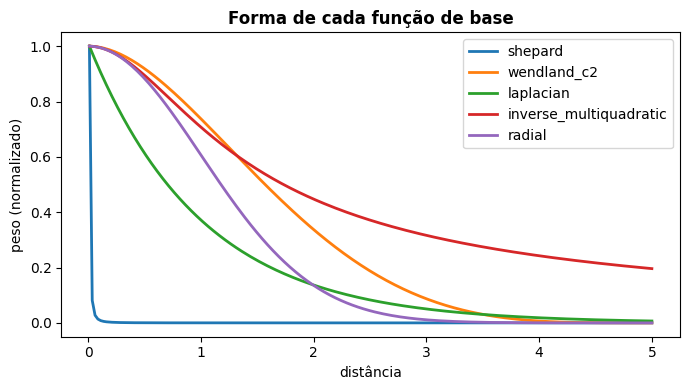

In [ ]:
EPS = 1e-8

BASIS_FUNCTIONS = {
    'shepard':                lambda d, z=2.0:  1.0 / (d**z + EPS),
    'wendland_c2':             lambda d, h=5.0:  (np.clip(1 - d/h, 0, None)**4) * (4*d/h + 1),
    'laplacian':               lambda d, eps=1.0: np.exp(-eps * d),
    'inverse_multiquadratic':  lambda d, c=1.0:  1.0 / np.sqrt(d**2 + c**2),
    'radial':                  lambda d, z=1.0:  np.exp(-(d**2) / (2*z**2 + EPS)),
}

# como cada uma se comporta? (peso vs. distância)
dists = np.linspace(0.01, 5, 200)
fig, ax = plt.subplots(figsize=(7, 4))
for nome, fn in BASIS_FUNCTIONS.items():
    pesos = fn(dists)
    ax.plot(dists, pesos / pesos.max(), label=nome, linewidth=2)
ax.set_xlabel('distância'); ax.set_ylabel('peso (normalizado)')
ax.set_title('Forma de cada função de base', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

## 3. A classe FEMa

Para cada ponto novo: acha os `k` vizinhos mais próximos (força bruta), calcula o
peso de cada um com a função de base escolhida, e tira a média ponderada dos rótulos.

In [ ]:
class FEMaClassifier:
    def __init__(self, basis='shepard', basis_kwargs=None, k=15):
        self.basis = basis
        self.basis_kwargs = basis_kwargs or {}
        self.k = k

    def fit(self, X, y):
        # Guarda os dados de treino
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        # Converte para array NumPy
        X = np.asarray(X, dtype=float)

        # Calcula todas as distâncias entre:
        # cada ponto de X (entrada nova) e
        # cada ponto do treino
        D = pairwise_distance(X, self.X_train)

        # # aqui: garante que k não passe do número de amostras de treino
        # Se houver menos dados de treino do que k, usa o máximo possível.
        # D.shape[1] = número de colunas = número de amostras em self.X_train
        k = min(self.k, D.shape[1])

        # Ordena cada linha (cada amostra nova) pela distância
        # e pega os k vizinhos mais próximos
        idx = np.argsort(D, axis=1)[:, :k]

        # Pega as distâncias desses vizinhos selecionados
        dist_k = np.take_along_axis(D, idx, axis=1)

        # Calcula os pesos para cada vizinho usando a função de base escolhida
        pesos = BASIS_FUNCTIONS[self.basis](dist_k, **self.basis_kwargs)

        preds = []
        for i in range(len(X)):
            # Acumula o peso por classe dentre os k vizinhos
            votos = {}
            for classe, peso in zip(self.y_train[idx[i]], pesos[i]):
                votos[classe] = votos.get(classe, 0) + peso

            # Escolhe a classe com maior soma de pesos
            preds.append(max(votos, key=votos.get))
        return np.array(preds)

## 4. Testando: fronteira de decisão, uma por função de base

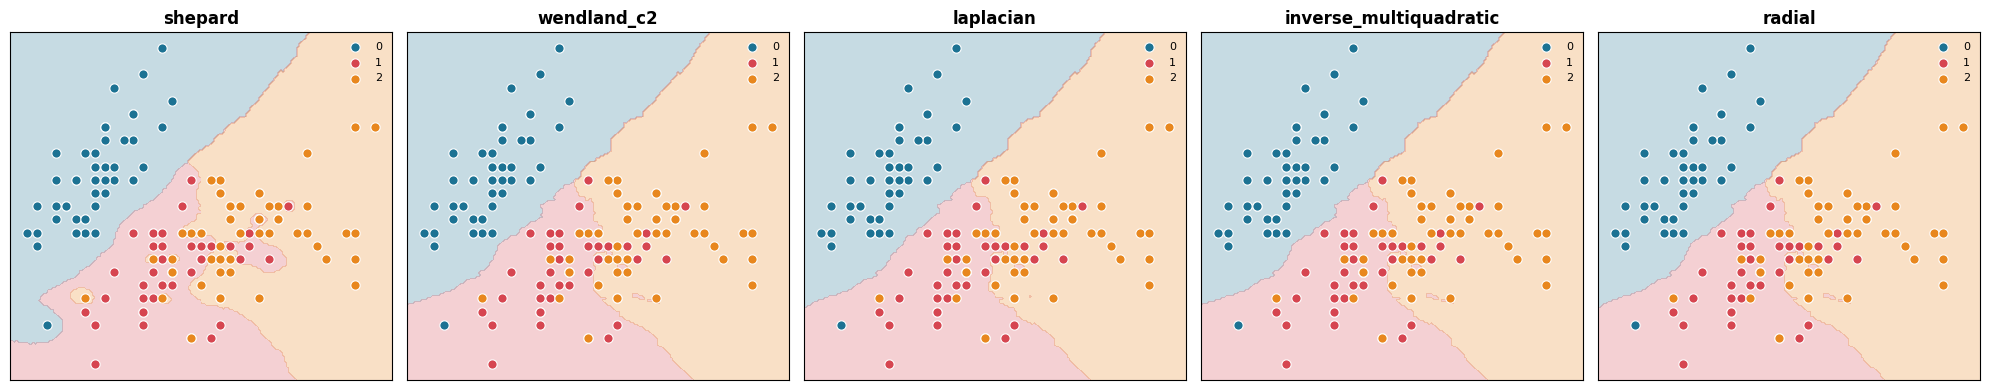

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from viz import plot_decision_boundary

# Carrega o dataset Iris
iris = load_iris()

# Pega só as 2 primeiras features para visualizar melhor a fronteira
# e padroniza com z-score (média 0, variância 1)
X2d = StandardScaler().fit_transform(iris.data[:, :2])
y2d = iris.target

# Cria 5 subplots, um para cada função de base
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# BASIS_FUNCTIONS é um dicionário; a ordem das chaves é a ordem de inserção
# então aqui vai iterar em: shepard, wendland_c2, laplacian, inverse_multiquadratic, radial
for ax, nome in zip(axes, BASIS_FUNCTIONS):
    # Cria um classificador FEMa usando a função de base atual
    # e k=20 vizinhos
    clf = FEMaClassifier(basis=nome, k=20)

    # Plota a fronteira de decisão do classificador no espaço 2D
    # e o título do subplot é o nome da função de base
    plot_decision_boundary(clf, X2d, y2d, ax=ax, title=nome)

# Ajusta espaçamento e mostra tudo
plt.tight_layout()
plt.show()

## 5. Checagem: FEMa (Shepard) deve bater com o KNN ponderado do Dia 1

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X2d, y2d, test_size=0.3, random_state=0, stratify=y2d)

fema_shepard = FEMaClassifier(basis='shepard', basis_kwargs={'z': 2.0}, k=15).fit(X_train, y_train)
acc = (fema_shepard.predict(X_test) == y_test).mean()
print(f'FEMa (Shepard, z=2) -> acurácia: {acc:.4f}')
print('(era pra ficar bem perto do KNN ponderado com p=2 do Dia 1 -- é a mesma fórmula)')

FEMa (Shepard, z=2) -> acurácia: 0.7111
(era pra ficar bem perto do KNN ponderado com p=2 do Dia 1 -- é a mesma fórmula)


---
**Próximos passos (fora do escopo de hoje, ficam de exercício):**
- **Estruturas de dados espaciais** (KD-Tree, Ball-Tree): a busca por vizinhos aqui é força bruta (O(n) por consulta) — trocar por uma árvore espacial acelera isso sem mudar o resto do código.
- **Verificação estatística rigorosa** (Friedman + Wilcoxon + Holm, como no pôster do CIC): aqui comparamos só acurácia simples; para afirmar que uma função de base é "melhor" de verdade, é preciso testar se a diferença é estatisticamente significativa, não só olhar o número.
